**Savings Accounts Prediction Model**

Objective

The objective of this notebook is to predict Savings_Accounts using UK macroeconomic variables and lagged financial indicators. The notebook develops and compares three predictive models:

Linear Regression
Random Forest Regressor
XGBoost Regressor

The models are evaluated using R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)

**Load Dataset**

In [2]:
df = pd.read_csv("Final_DS.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Net_Consumer_Credit,Credit_Card_Lending,Consumer_Credit
0,2008-01-01,2008,January,5.50,2.2,5.2,65.6,0.4,33417,224159,71326,288,183,105
1,2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,1200,363,837
2,2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,432,319,113
3,2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,514,179,335
4,2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,370,752,-382


**Feature Engineering**

In [3]:
# Create lag features
df["Savings_Lag1"] = df["Savings_Accounts"].shift(1)
df["ConsumerCredit_Lag1"] = df["Consumer_Credit"].shift(1)

# Remove rows with missing lag values
df_model = df.dropna().reset_index(drop=True)

df_model.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Net_Consumer_Credit,Credit_Card_Lending,Consumer_Credit,Savings_Lag1,ConsumerCredit_Lag1
0,2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,1200,363,837,224159.0,105.0
1,2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,432,319,113,226772.0,837.0
2,2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,514,179,335,227769.0,113.0
3,2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,370,752,-382,233766.0,335.0
4,2008-06-01,2008,June,5.00,3.8,5.5,64.2,-0.5,33348,241184,35391,81,465,-384,237820.0,-382.0


**Feature Selection**

In [4]:
features = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "Savings_Lag1",
    "ConsumerCredit_Lag1"
]

X = df_model[features]
y = df_model["Savings_Accounts"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (215, 6)
Target Shape: (215,)


**Correlation Analysis**

In [5]:
corr_matrix = df_model[features + ["Savings_Accounts"]].corr()

savings_corr = corr_matrix["Savings_Accounts"].sort_values(ascending=False)

savings_corr

Savings_Accounts       1.000000
Savings_Lag1           0.998357
Unemployment_Rate      0.712650
Bank_Rate              0.381939
CPI                    0.084150
GDP_Growth            -0.070372
ConsumerCredit_Lag1   -0.442649
Name: Savings_Accounts, dtype: float64

**Multicollinearity Analysis (VIF)**

In [6]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data

,Feature,VIF
4,Savings_Lag1,196.681946
3,Unemployment_Rate,151.298294
0,Bank_Rate,9.805386
1,CPI,2.967007
5,ConsumerCredit_Lag1,1.279392
2,GDP_Growth,1.040722


**Chronological Train/Test Split**

In [7]:
split = int(len(df_model) * 0.8)

train = df_model.iloc[:split]
test = df_model.iloc[split:]

X_train = train[features]
X_test = test[features]

y_train = train["Savings_Accounts"]
y_test = test["Savings_Accounts"]

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (172, 6)
Testing Shape : (43, 6)


**Feature Normalization**

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(172, 6) (43, 6)


**Linear Regression**

In [9]:
from sklearn.linear_model import LinearRegression

# Train the Linear Regression model
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Linear Regression Evaluation**

In [10]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results")
print("R² Score :", round(lr_r2, 4))
print("MAE      :", round(lr_mae, 2))
print("RMSE     :", round(lr_rmse, 2))

Linear Regression Results
R² Score : 0.9931
MAE      : 2478.41
RMSE     : 3074.12


**Ordinary Least Squares (OLS) Regression Summary**

In [11]:
import statsmodels.api as sm

# Add intercept term
X_train_sm = sm.add_constant(X_train_scaled)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Display statistical summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:       Savings_Accounts   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 2.718e+04
Date:                Fri, 14 Aug 2026   Prob (F-statistic):          2.67e-244
Time:                        01:08:16   Log-Likelihood:                -1506.8
No. Observations:                 172   AIC:                             3028.
Df Residuals:                     165   BIC:                             3050.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.14e+05    120.142   1781.325      0.0

**Linear Regression Coefficients**

In [12]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
4,Savings_Lag1,47611.656071
0,Bank_Rate,1030.985238
1,CPI,530.194365
3,Unemployment_Rate,419.678349
5,ConsumerCredit_Lag1,-276.458567
2,GDP_Growth,-375.253983


Actual vs Predicted Savings Accounts (Linear Regression)

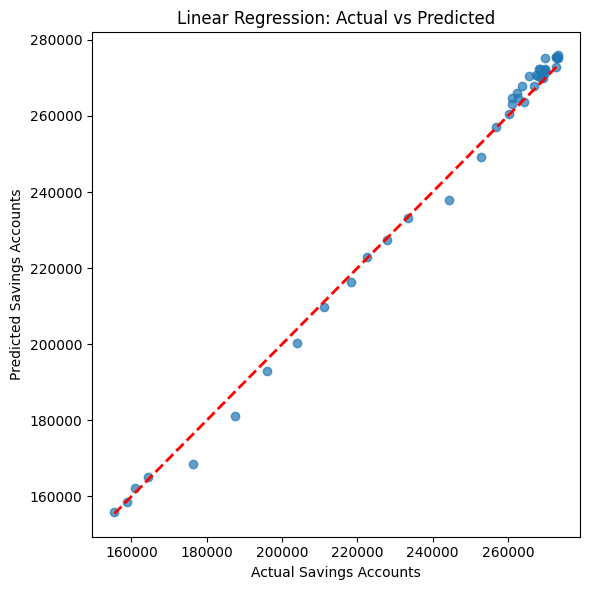

In [26]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Savings Accounts")
plt.ylabel("Predicted Savings Accounts")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

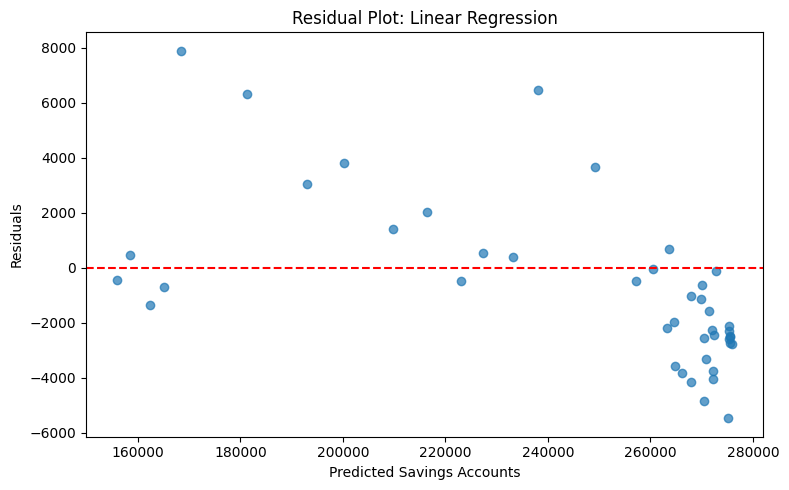

In [27]:
# Calculate residuals
lr_residuals = y_test - y_pred_lr

plt.figure(figsize=(8,5))

plt.scatter(y_pred_lr, lr_residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Savings Accounts")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression")
plt.tight_layout()
plt.show()

**Random Forest Regression**

In [13]:
from sklearn.ensemble import RandomForestRegressor

# Train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**Random Forest Evaluation**

In [14]:
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Results")
print("R² Score :", round(rf_r2, 4))
print("MAE      :", round(rf_mae, 2))
print("RMSE     :", round(rf_rmse, 2))

Random Forest Results
R² Score : 0.9692
MAE      : 4518.93
RMSE     : 6510.46


**Random Forest Feature Importance**

In [15]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
4,Savings_Lag1,0.996194
3,Unemployment_Rate,0.002093
1,CPI,0.001051
2,GDP_Growth,0.000389
5,ConsumerCredit_Lag1,0.000254
0,Bank_Rate,0.000019


**Actual vs Predicted Savings Accounts**

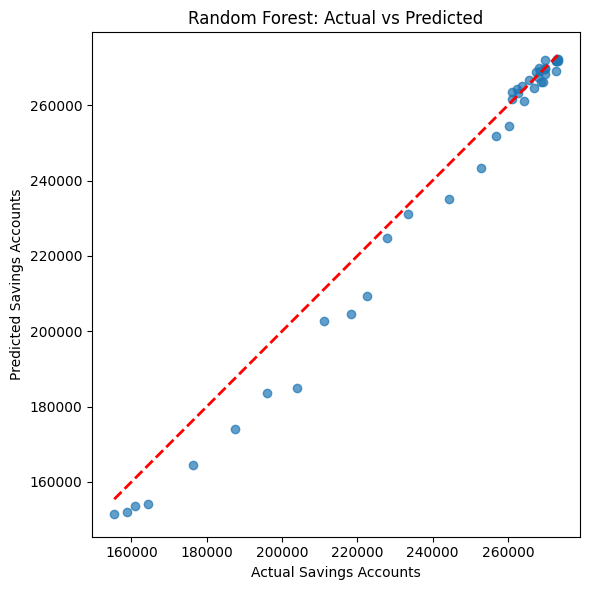

In [16]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Savings Accounts")
plt.ylabel("Predicted Savings Accounts")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

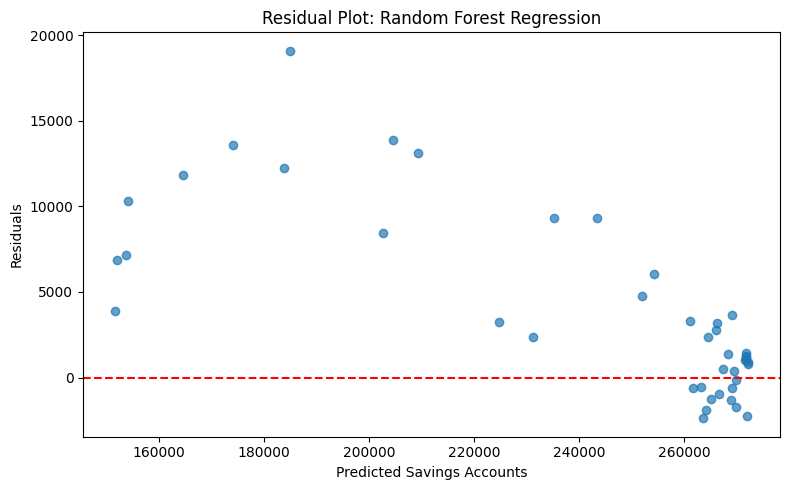

In [17]:
# Calculate residuals
rf_residuals = y_test - y_pred_rf

plt.figure(figsize=(8,5))

plt.scatter(y_pred_rf, rf_residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Savings Accounts")
plt.ylabel("Residuals")
plt.title("Residual Plot: Random Forest Regression")
plt.tight_layout()
plt.show()

**XGBoost Regression**

In [18]:
from xgboost import XGBRegressor

# Train the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Generate predictions
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


**XGBoost Evaluation**

In [19]:
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost Results")
print("R² Score :", round(xgb_r2, 4))
print("MAE      :", round(xgb_mae, 2))
print("RMSE     :", round(xgb_rmse, 2))

XGBoost Results
R² Score : 0.7495
MAE      : 16902.29
RMSE     : 18552.15


**XGBoost Feature Importance**

In [20]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
4,Savings_Lag1,0.556783
3,Unemployment_Rate,0.368321
0,Bank_Rate,0.053010
1,CPI,0.010522
5,ConsumerCredit_Lag1,0.009608
2,GDP_Growth,0.001755


**Actual vs Predicted Savings Accounts**

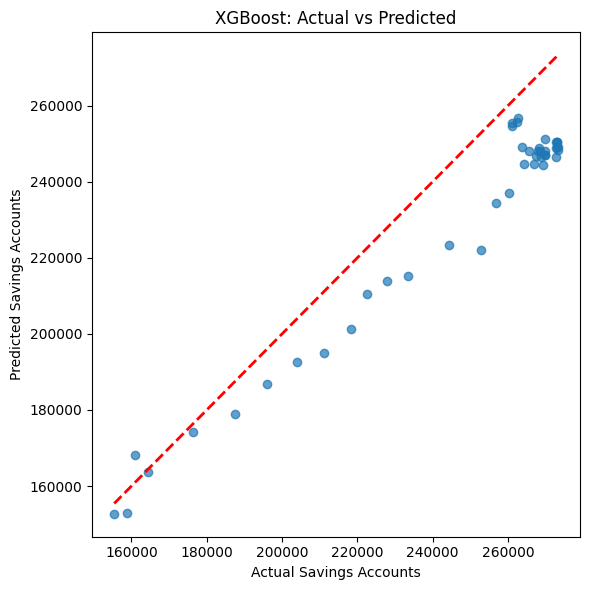

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Savings Accounts")
plt.ylabel("Predicted Savings Accounts")
plt.title("XGBoost: Actual vs Predicted")
plt.tight_layout()
plt.show()

**XGBoost Residual Analysis**

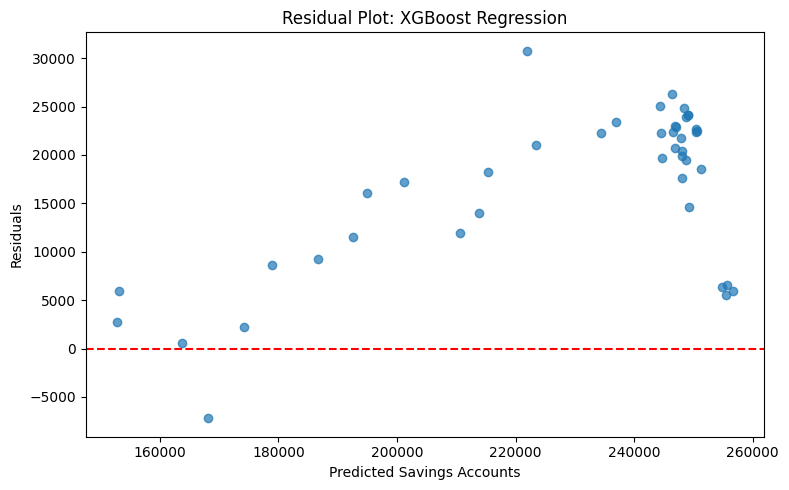

In [22]:
# Calculate residuals
xgb_residuals = y_test - y_pred_xgb

plt.figure(figsize=(8,5))

plt.scatter(y_pred_xgb, xgb_residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Savings Accounts")
plt.ylabel("Residuals")
plt.title("Residual Plot: XGBoost Regression")
plt.tight_layout()
plt.show()

**Model Comparison**

In [23]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R²": [lr_r2, rf_r2, xgb_r2],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse]
})

comparison = comparison.sort_values(by="R²", ascending=False)

comparison

,Model,R²,MAE,RMSE
0,Linear Regression,0.993122,2478.414464,3074.123634
1,Random Forest,0.969151,4518.929117,6510.457212
2,XGBoost,0.749504,16902.289062,18552.154376


**Model Comparison Visualization**

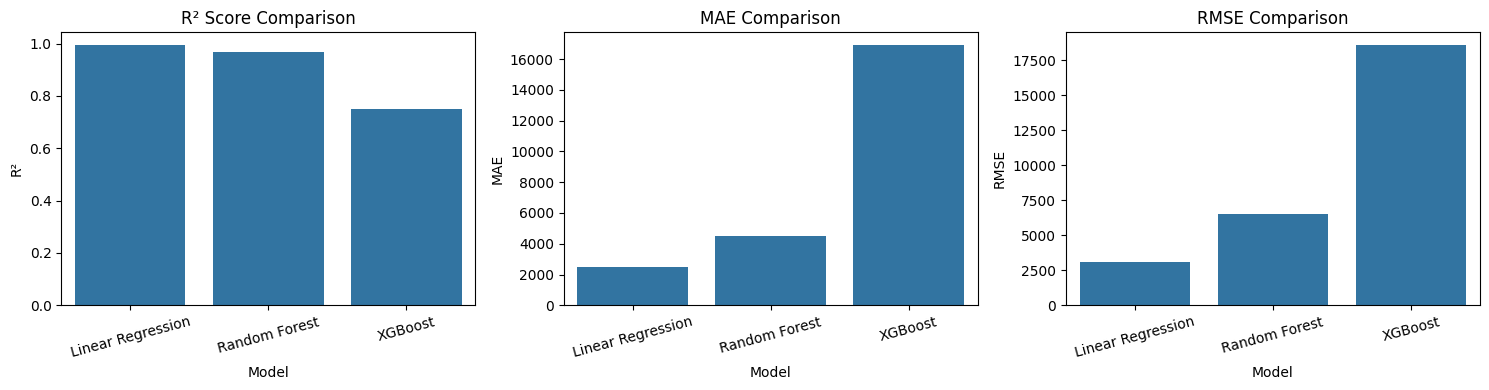

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# R² comparison
sns.barplot(
    data=comparison,
    x="Model",
    y="R²",
    ax=axes[0]
)
axes[0].set_title("R² Score Comparison")
axes[0].tick_params(axis="x", rotation=15)

# MAE comparison
sns.barplot(
    data=comparison,
    x="Model",
    y="MAE",
    ax=axes[1]
)
axes[1].set_title("MAE Comparison")
axes[1].tick_params(axis="x", rotation=15)

# RMSE comparison
sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE",
    ax=axes[2]
)
axes[2].set_title("RMSE Comparison")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Final Model Selection

In [25]:
best_model_name = comparison.iloc[0]["Model"]

print(f"Best Model for Savings Accounts: {best_model_name}")

Best Model for Savings Accounts: Linear Regression
